In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

investors = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

In [11]:
nav.info()

<class 'pandas.DataFrame'>
Index: 46000 entries, 5750 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.4 MB


In [7]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

In [10]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [12]:
investors.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [13]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [14]:
var_results = []

In [15]:
for fund in nav['amfi_code'].unique():
    temp = nav[
        nav['amfi_code']==fund
    ]
    returns = temp['daily_return'].dropna()
    var95 = np.percentile(
        returns,
        5
    )
    cvar95 = returns[
        returns <= var95
    ].mean()
    var_results.append([
        fund,
        var95,
        cvar95
    ])

In [16]:
var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        'Fund',
        'VaR_95',
        'CVaR_95'
    ]
)

In [17]:
var_cvar_df.head()

,Fund,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [18]:
var_cvar_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Fund     40 non-null     int64  
 1   VaR_95   40 non-null     float64
 2   CVaR_95  40 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.1 KB


In [19]:
var_cvar_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

In [20]:
nav['rolling_mean'] = (
    nav.groupby('amfi_code')
    ['daily_return']
    .transform(
        lambda x:
        x.rolling(90).mean()
    )
)

In [21]:
nav['rolling_std'] = (
    nav.groupby('amfi_code')
    ['daily_return']
    .transform(
        lambda x:
        x.rolling(90).std()
    )
)

In [22]:
nav['rolling_sharpe'] = (
    nav['rolling_mean']
    /
    nav['rolling_std']
) * np.sqrt(252)

In [23]:
funds = nav['amfi_code'].unique()[:5]

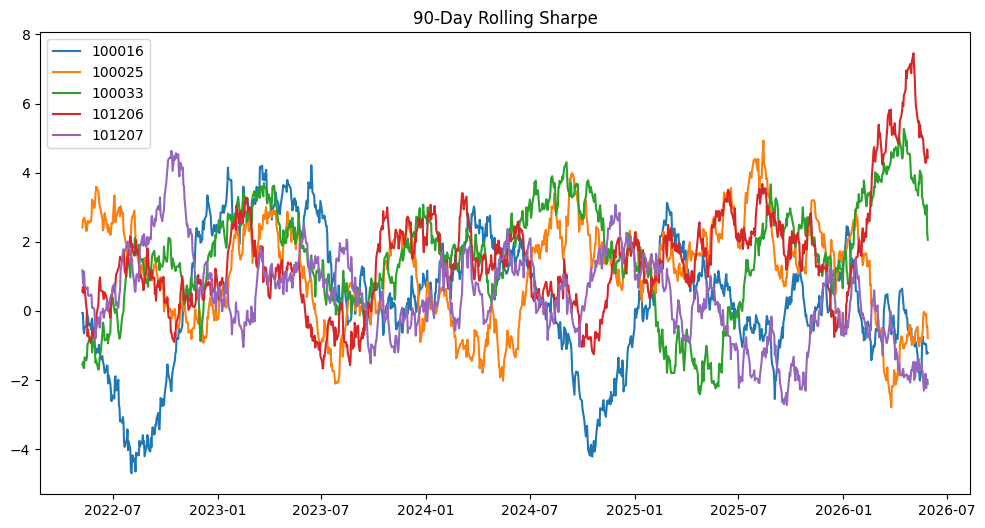

In [24]:
plt.figure(figsize=(12,6))
for fund in funds:
    temp = nav[
        nav['amfi_code']==fund
    ]
    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=fund
    )
plt.legend()
plt.title("90-Day Rolling Sharpe")
plt.show()

In [25]:
plt.savefig(
    "rolling_sharpe_chart.png"
)

<Figure size 640x480 with 0 Axes>

In [26]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [27]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  str           
 1   transaction_date    32778 non-null  datetime64[us]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  str           
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  str           
 6   city                32778 non-null  str           
 7   city_tier           32778 non-null  str           
 8   age_group           32778 non-null  str           
 9   gender              32778 non-null  str           
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  str           
 12  kyc_status          32778 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(9)
memory

In [28]:
first_year = (
    transactions
    .groupby('investor_id')
    ['transaction_date']
    .min()
)

In [29]:
first_year = (
    first_year.dt.year
    .reset_index()
)

In [30]:
first_year.columns = [
    'investor_id',
    'cohort_year'
]

In [31]:
transactions = transactions.merge(
    first_year,
    on='investor_id'
)

In [33]:
cohort_analysis = (
    transactions
    .groupby('cohort_year')
    ['amount_inr']
    .mean()
)

In [34]:
transactions = transactions.sort_values(
    [
        'investor_id',
        'transaction_date'
    ]
)

In [35]:
transactions['gap_days'] = (
    transactions.groupby(
        'investor_id'
    )['transaction_date']
    .diff()
    .dt.days
)

In [36]:
at_risk = transactions[
    transactions['gap_days'] > 35
]

In [37]:
len(at_risk)

15153

In [38]:
fund_metrics = nav.groupby('amfi_code').agg(
    mean_return=('daily_return','mean'),
    volatility=('daily_return','std')
).reset_index()

fund_metrics['sharpe_ratio'] = (
    fund_metrics['mean_return']
    /
    fund_metrics['volatility']
) * np.sqrt(252)

fund_metrics.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [39]:
portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [40]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [41]:
portfolio['weight_sq'] = (
    portfolio['weight_pct']/100
)**2

In [42]:
hhi = (
    portfolio
    .groupby('stock_name')
    ['weight_sq']
    .sum()
    .reset_index()
)
hhi.columns = [
    'Fund',
    'HHI'
]
hhi.head()

,Fund,HHI
0,Adani Ports & SEZ Ltd,0.112540
1,Asian Paints Ltd,0.095912
2,Axis Bank Ltd,0.220126
3,Bajaj Finance Ltd,0.151759
4,Bharti Airtel Ltd,0.237031


In [43]:
def concentration(hhi):
    if hhi > 0.25:
        return "Highly Concentrated"
    elif hhi > 0.15:
        return "Moderately Concentrated"
    else:
        return "Diversified"
hhi['Category'] = hhi['HHI'].apply(
    concentration
)
hhi.head()

,Fund,HHI,Category
0,Adani Ports & SEZ Ltd,0.112540,Diversified
1,Asian Paints Ltd,0.095912,Diversified
2,Axis Bank Ltd,0.220126,Moderately Concentrated
3,Bajaj Finance Ltd,0.151759,Moderately Concentrated
4,Bharti Airtel Ltd,0.237031,Moderately Concentrated


In [44]:
hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

,Fund,HHI,Category
8,Grasim Industries Ltd,0.278833,Highly Concentrated
19,NTPC Ltd,0.256989,Highly Concentrated
14,Infosys Ltd,0.243727,Moderately Concentrated
4,Bharti Airtel Ltd,0.237031,Moderately Concentrated
24,Sun Pharmaceutical Industries,0.233243,Moderately Concentrated
2,Axis Bank Ltd,0.220126,Moderately Concentrated
29,Wipro Ltd,0.198386,Moderately Concentrated
27,Titan Company Ltd,0.198049,Moderately Concentrated
9,HCL Technologies Ltd,0.186957,Moderately Concentrated
11,Hindustan Unilever Ltd,0.178849,Moderately Concentrated


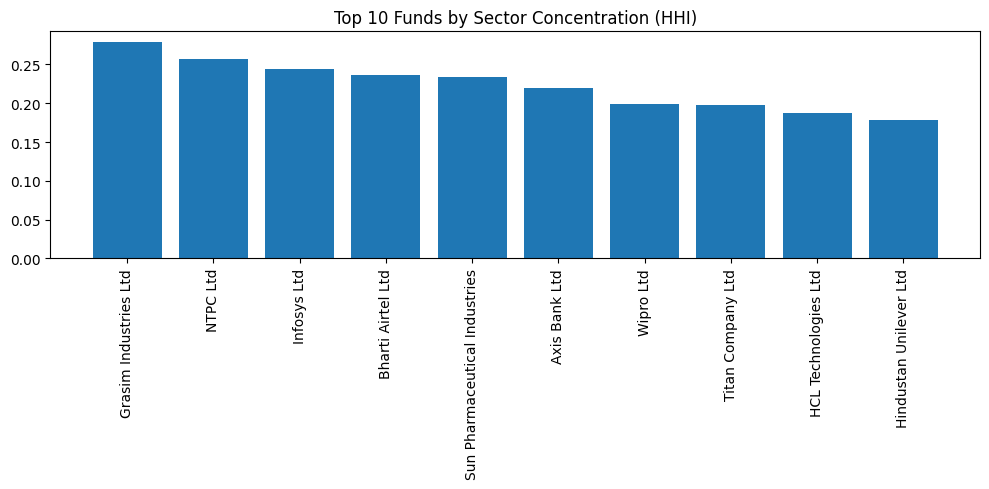

In [45]:
import matplotlib.pyplot as plt
top10 = hhi.sort_values(
    'HHI',
    ascending=False
).head(10)
plt.figure(figsize=(10,5))
plt.bar(
    top10['Fund'],
    top10['HHI']
)
plt.xticks(rotation=90)
plt.title(
    "Top 10 Funds by Sector Concentration (HHI)"
)
plt.tight_layout()
plt.show()

In [46]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date', 'weight_sq'],
      dtype='str')